In [1]:
import numpy as np
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import umap

In [2]:
training_bubble = np.load("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/analysis/check_latent/latent_list/fgn_latent_upgrade/FGN_01100-03000_add_bubble.npy")
training_data = np.load("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/analysis/check_latent/latent_list/fgn_latent_upgrade/FGN_01100-03000_add.npy")
test_bubble = np.load("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/analysis/check_latent/latent_list/fgn_latent_upgrade/add_test_bubble.npy")
test_data = np.load("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/analysis/check_latent/latent_list/fgn_latent_upgrade/add_test.npy")
# test_03400_bubble = np.load("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/analysis/check_latent/latent_list/fgn_latent/FGN_03400+0000_test_bubble.npy")
# test_03400_data = np.load("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/analysis/check_latent/latent_list/fgn_latent/FGN_03400+0000_test.npy")

In [3]:
training_bubble_label = [0] * len(training_bubble)
training_data_label = [1] * len(training_data)

test_bubble_label = [0] * len(test_bubble)
test_data_label = [1] * len(test_data)

# test_03400_bubble_label = [0] * len(test_03400_bubble)
# test_03400_data_label = [1] * len(test_03400_data)

In [4]:
print(len(training_bubble))
print(len(training_data))
print(len(test_bubble))
print(len(test_data))
# print(len(test_03400_bubble))
# print(len(test_03400_data))

1296
7776
133
133


In [5]:
# trainig_dataのまとめ
training_data_set = np.concatenate((training_bubble, training_data))
training_labels_set = np.concatenate((training_bubble_label, training_data_label))

# FGN_03300まとめ
test_data_set = np.concatenate((test_bubble, test_data))
test_labels_set = np.concatenate((test_bubble_label, test_data_label))

# FGN_03400まとめ
# test_03400_data_set = np.concatenate((test_03400_bubble, test_03400_data))
# test_03400_labels_set = np.concatenate((test_03400_bubble_label, test_03400_data_label))

# 全データまとめ
all_data_set = np.concatenate((training_data_set, test_data_set,))
all_labels_set = np.concatenate((training_labels_set, test_labels_set,))

In [20]:
# 1. UMAPのモデルを作成
# 基本はデフォルト設定のままで強力に機能します
n_neighbors = 50
min_dist = 0.1
random_state = 42
n_jobs = 1 
reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, random_state=random_state, n_jobs=n_jobs)

# 2. 100次元のデータを2次元に変換（低次元空間への埋め込み）
embedding = reducer.fit_transform(training_data_set)

In [21]:
print(len(training_data_set))
print(len(test_data_set))
# print(len(test_03400_data_set))
print(len(all_data_set))

9072
266
9338


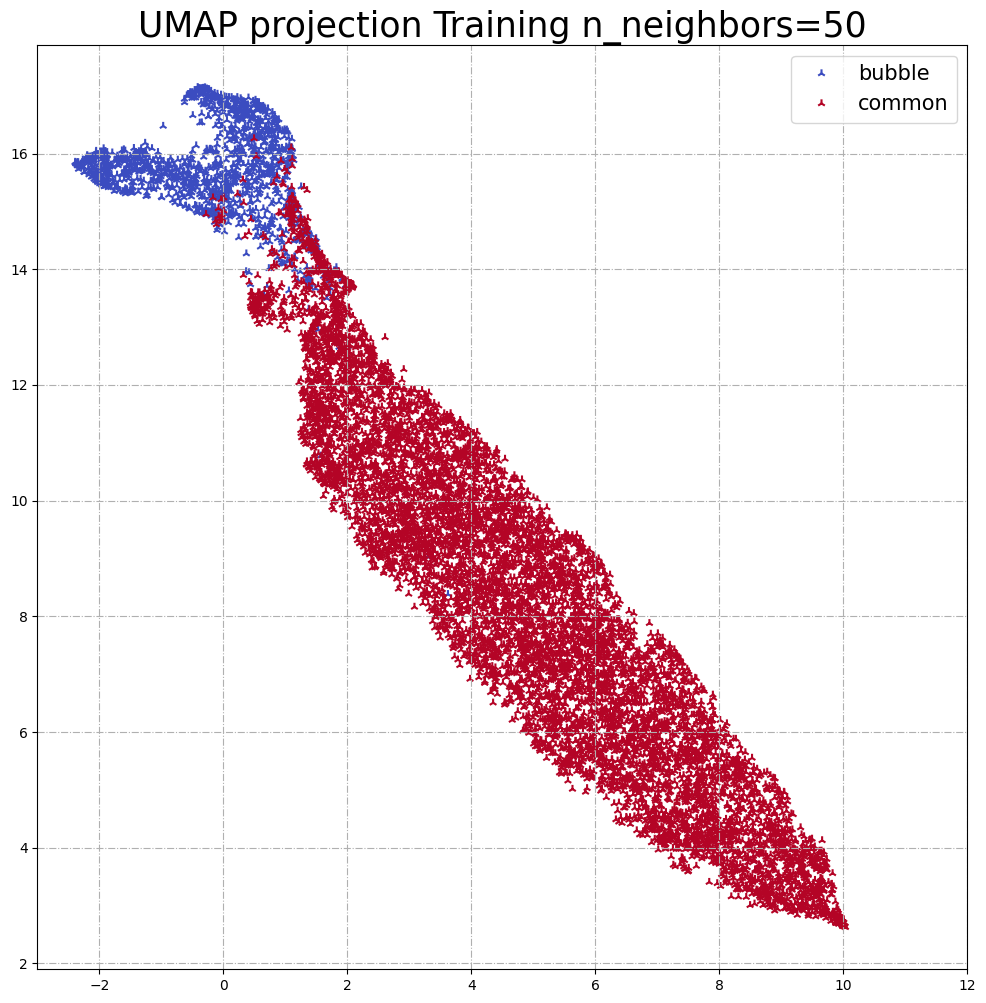

In [23]:
# 4. 2次元になったデータをグラフに描画
plt.figure(figsize=(12, 12))

# ※ c に渡すデータは数値（例: no=0, bubble=1）に変換されている前提です
scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=training_labels_set,
    cmap="coolwarm",  # 2クラスなら「赤・青」に分かれる bwr や coolwarm などが見やすいです
    marker="2",
)

# --- 凡例（Legend）の追加処理 ---
handles, _ = scatter.legend_elements()
plt.legend(handles, ["bubble", "common"], loc="upper right", fontsize=15)
# --------------------------------
plt.xlim(-3, 12)
plt.title(f"UMAP projection Training n_neighbors={n_neighbors}", fontsize=25)
plt.grid(ls="dashdot")
# plt.savefig(f"UMAP_projection_Training_n_neighbors{n_neighbors}_min_dist{min_dist}_random_state{random_state}.png")
plt.show()

In [24]:
# testデータに対するfitting
embedding_test = reducer.transform(test_data_set)

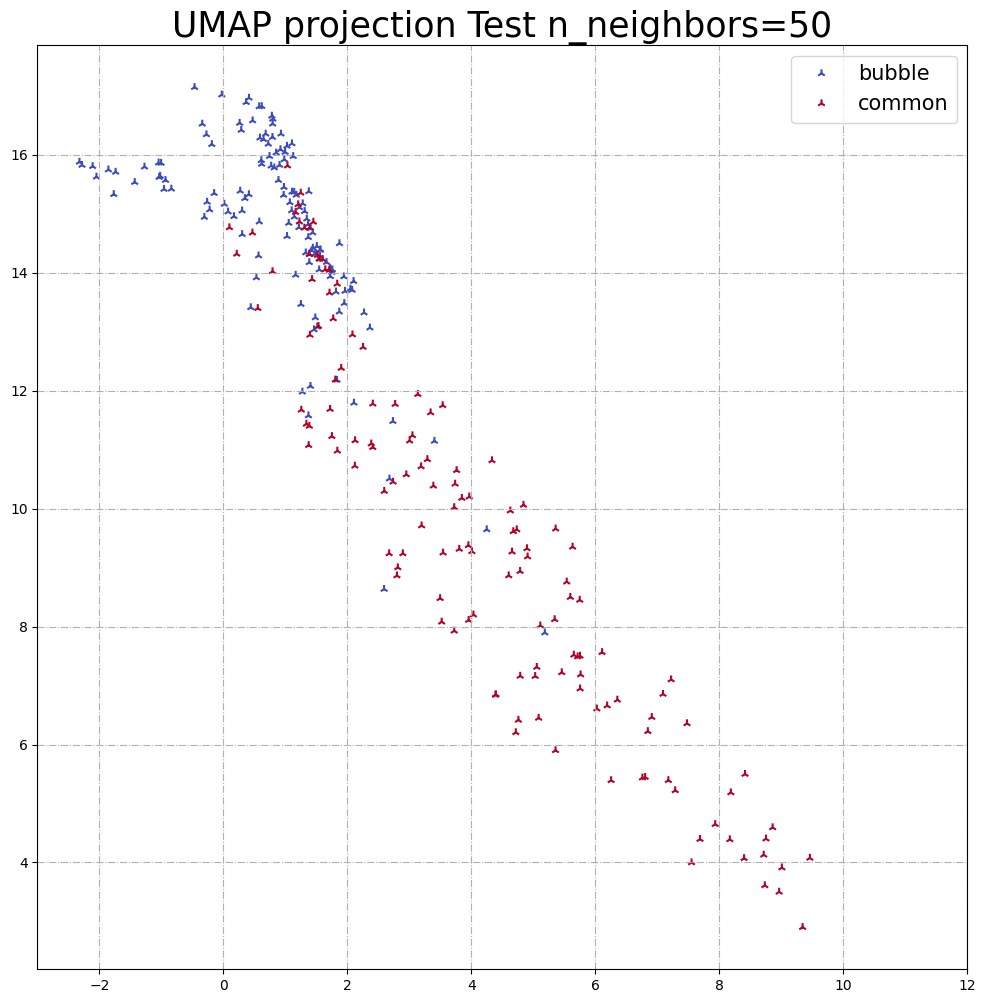

In [25]:
# 4. 2次元になったデータをグラフに描画
plt.figure(figsize=(12, 12))

# ※ c に渡すデータは数値（例: no=0, bubble=1）に変換されている前提です
scatter = plt.scatter(
    embedding_test[:, 0],
    embedding_test[:, 1],
    c=test_labels_set,
    cmap="coolwarm",  # 2クラスなら「赤・青」に分かれる bwr や coolwarm などが見やすいです
    marker="2",
)

# --- 凡例（Legend）の追加処理 ---
handles, _ = scatter.legend_elements()
plt.legend(handles, ["bubble", "common"], loc="upper right", fontsize=15)
# --------------------------------
plt.xlim(-3, 12)
plt.title(f"UMAP projection Test n_neighbors={n_neighbors}", fontsize=25)
plt.grid(ls="dashdot")
# plt.savefig(f"UMAP_projection_FGN_03300_n_neighbors{n_neighbors}_min_dist{min_dist}_random_state{random_state}.png")
plt.show()

In [26]:
# 全データセットに対するfitting
embedding_all = reducer.transform(all_data_set)

In [27]:
len(embedding_all)

9338

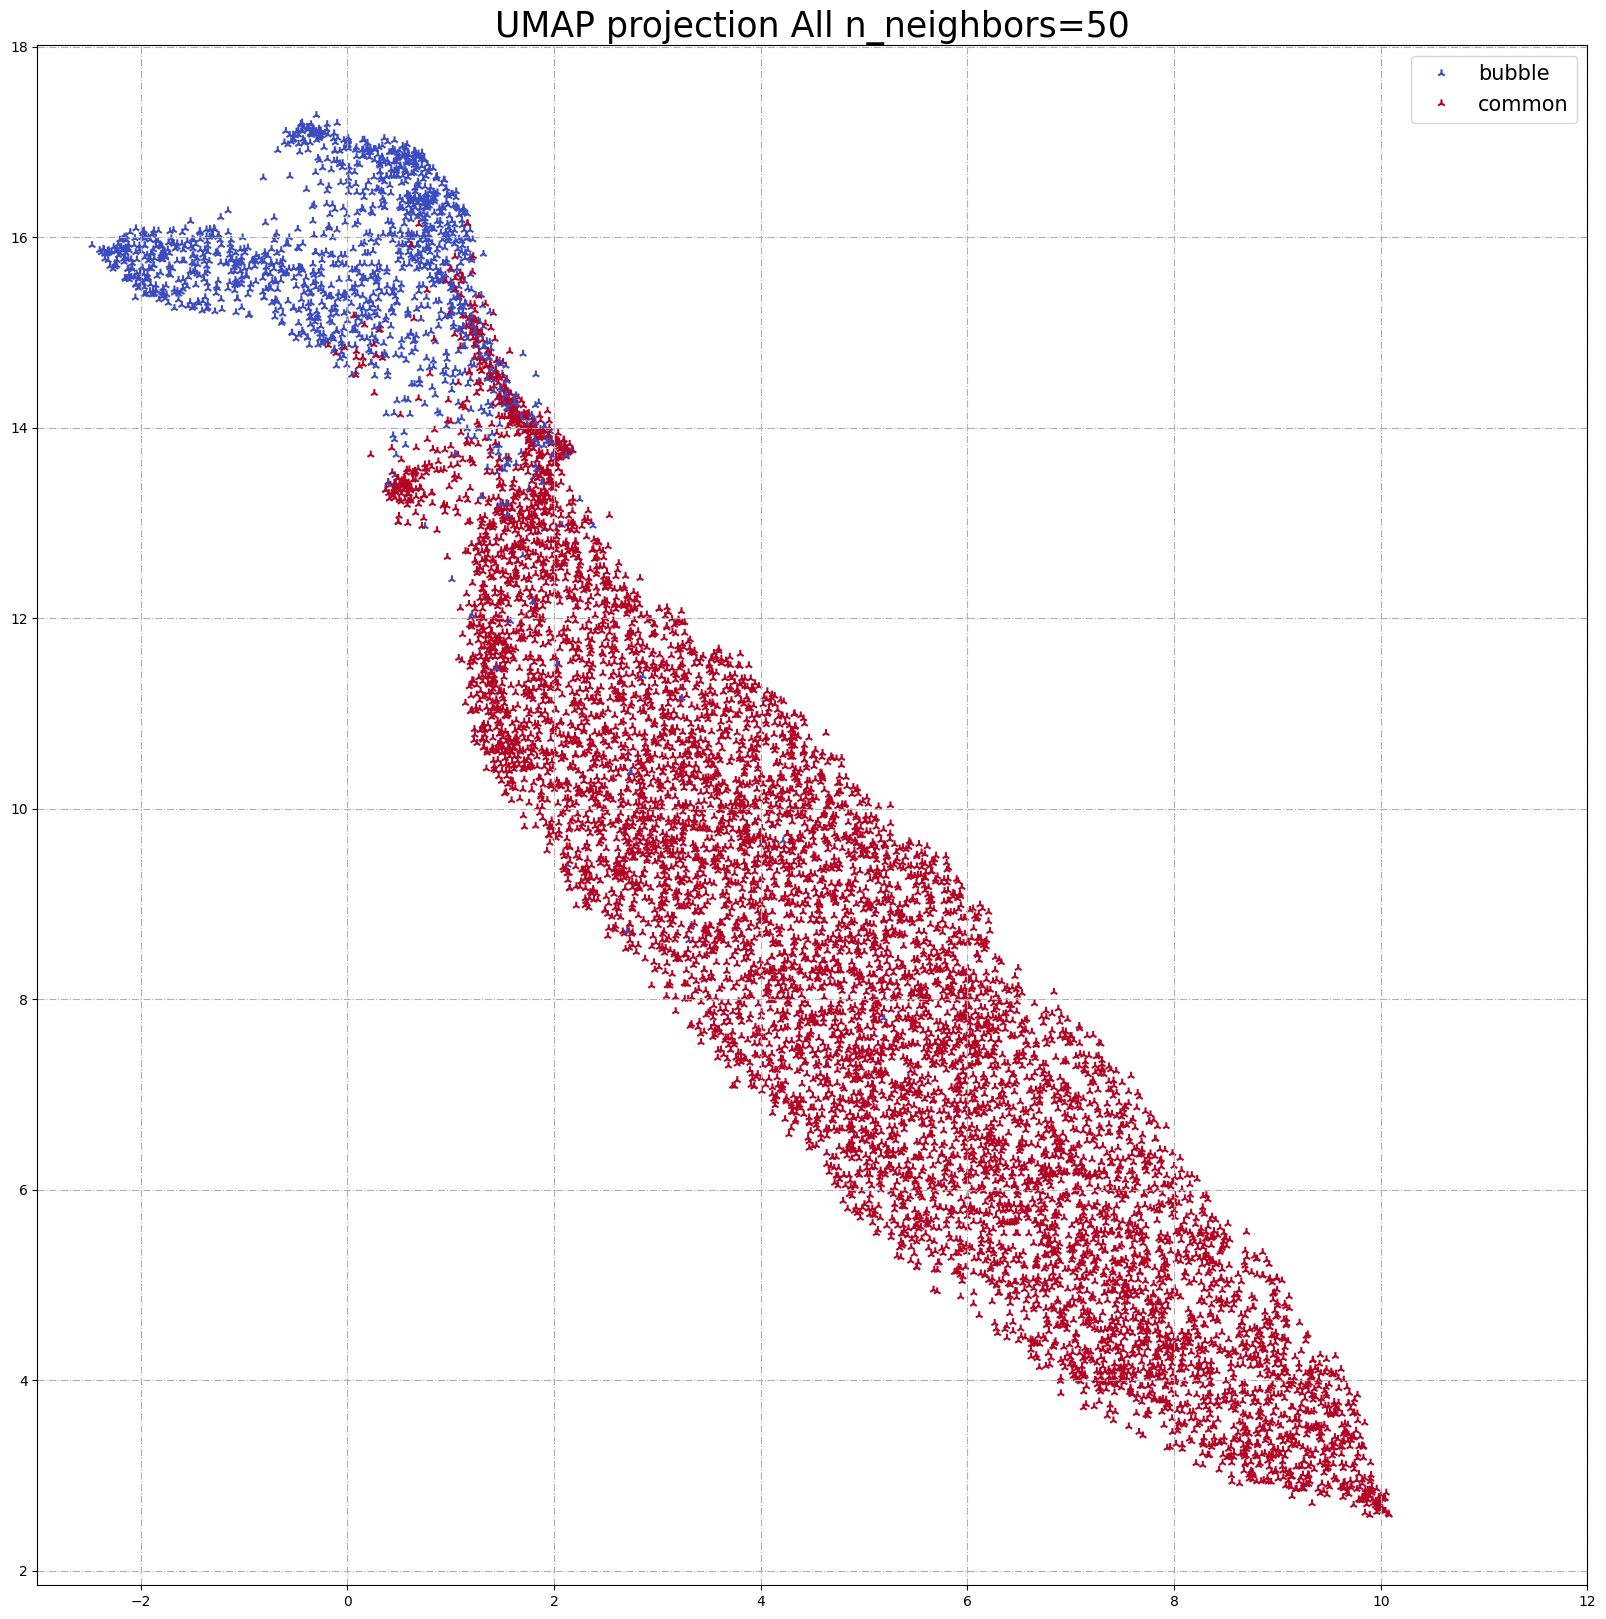

In [28]:
# 4. 2次元になったデータをグラフに描画
plt.figure(figsize=(20, 20))

# ※ c に渡すデータは数値（例: no=0, bubble=1）に変換されている前提です
scatter = plt.scatter(
    embedding_all[:, 0],
    embedding_all[:, 1],
    c=all_labels_set,
    cmap="coolwarm",  # 2クラスなら「赤・青」に分かれる bwr や coolwarm などが見やすいです
    marker="2",
)

# --- 凡例（Legend）の追加処理 ---
handles, _ = scatter.legend_elements()
plt.legend(handles, ["bubble", "common"], loc="upper right", fontsize=15)
# --------------------------------
plt.xlim(-3, 12)
plt.title(f"UMAP projection All n_neighbors={n_neighbors}", fontsize=25)
plt.grid(ls="dashdot")
# plt.savefig(f"UMAP_projection_All_n_neighbors{n_neighbors}_min_dist{min_dist}_random_state{random_state}.png")
plt.show()

## 学習データを薄く、テストデータを濃くしてプロット

In [29]:
# test_concate = np.concatenate((embedding_03300, embedding_03400))
# test_labels_concatenate = np.concatenate((test_03300_labels_set, test_03400_labels_set))

In [30]:
# --- 領域定義（変数名・構造は完全に固定） ---
# Region1
x_min_r1 = -1.7
x_max_r1 = -0.7
y_min_r1 = 16.8
y_max_r1 = 17.3

# Region2
x_min_r2 = 0
x_max_r2 = 1.0
y_min_r2 = 17.8 
y_max_r2 = 18.3

# Region3
x_min_r3 = 0
x_max_r3 = 1
y_min_r3 = 19
y_max_r3 = 19.5

# Region4
x_min_r4 = 2
x_max_r4 = 3
y_min_r4 = 18.3
y_max_r4 = 18.8

# Region5
x_min_r5 = 4.5
x_max_r5 = 5.5
y_min_r5 = 17
y_max_r5 = 17.5

# Region6
x_min_r6 = 6.5
x_max_r6 = 7.5
y_min_r6 = 16
y_max_r6 = 16.5

# Region7
x_min_r7 = 7.5
x_max_r7 = 8.5
y_min_r7 = 14.75
y_max_r7 = 15.25

# Region8
x_min_r8 = 9.5
x_max_r8 = 10.5
y_min_r8 = 13.5
y_max_r8 = 14

# Region9
x_min_r9 = 12
x_max_r9 = 13
y_min_r9 = 12
y_max_r9 = 12.5

# Region10
x_min_r10 = 14.2
x_max_r10 = 15.2
y_min_r10 = 10.5
y_max_r10 = 11

regions = [
    {"name": "region 1", "x": [x_min_r1, x_max_r1], "y": [y_min_r1, y_max_r1]},
    {"name": "region 2", "x": [x_min_r2, x_max_r2], "y": [y_min_r2, y_max_r2]},
    {"name": "region 3", "x": [x_min_r3, x_max_r3], "y": [y_min_r3, y_max_r3]},
    {"name": "region 4", "x": [x_min_r4, x_max_r4], "y": [y_min_r4, y_max_r4]},
    {"name": "region 5", "x": [x_min_r5, x_max_r5], "y": [y_min_r5, y_max_r5]},
    {"name": "region 6", "x": [x_min_r6, x_max_r6], "y": [y_min_r6, y_max_r6]},
    {"name": "region 7", "x": [x_min_r7, x_max_r7], "y": [y_min_r7, y_max_r7]},
    {"name": "region 8", "x": [x_min_r8, x_max_r8], "y": [y_min_r8, y_max_r8]},
    {"name": "region 9", "x": [x_min_r9, x_max_r9], "y": [y_min_r9, y_max_r9]},
    {"name": "region 10", "x": [x_min_r10, x_max_r10], "y": [y_min_r10, y_max_r10]},
]

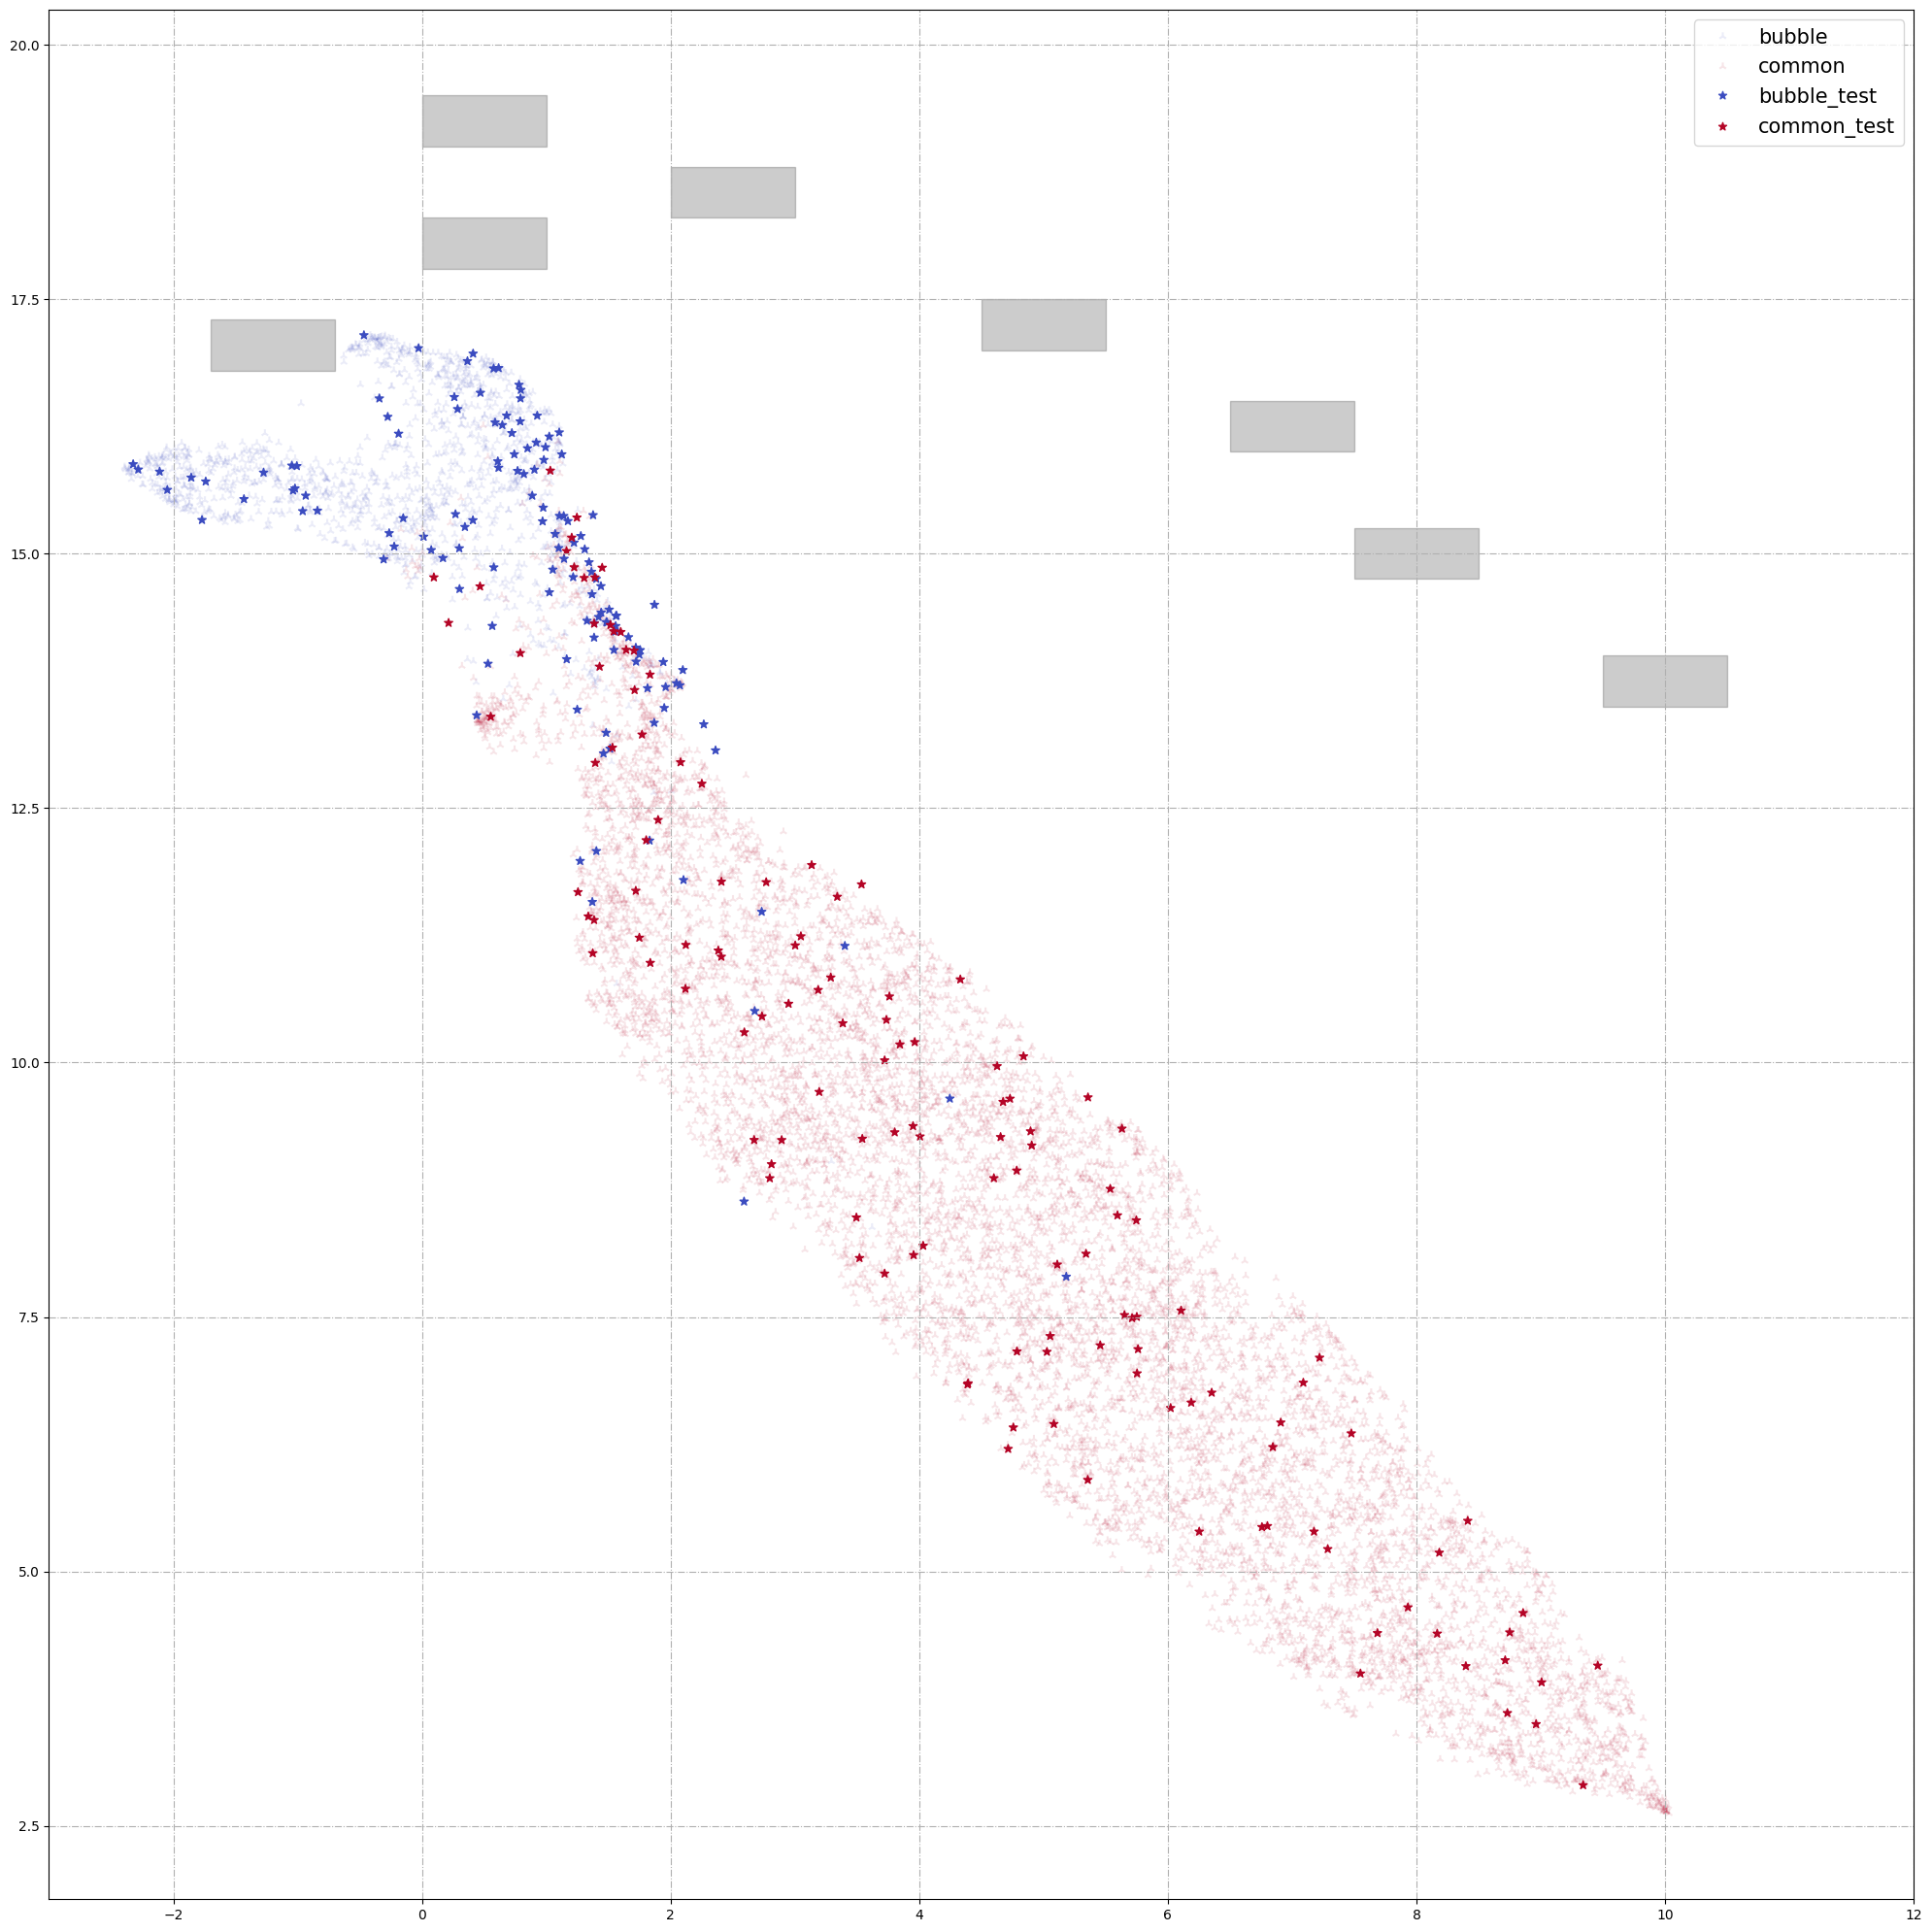

In [31]:

# --- 描画処理 ---
plt.figure(figsize=(20, 20))

# 1. 元のデータ（no, bubble）をプロット
scatter_orig = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=training_labels_set,
    cmap="coolwarm",
    marker="2",
    alpha=0.1,
)

scatter_test = plt.scatter(
    embedding_test[:, 0],
    embedding_test[:, 1],
    c=test_labels_set, 
    cmap="coolwarm",
    s=40,
    marker="*",       
)

# 2. 凡例（Legend）の調整
handles_orig, _ = scatter_orig.legend_elements()
handles_test, _ = scatter_test.legend_elements()

all_handles = handles_orig + handles_test
all_labels = ["bubble", "common", "bubble_test", "common_test"]
plt.legend(all_handles, all_labels, loc="upper right", fontsize=15)

# 3. 領域の網掛け描画（ループ処理に集約）
for r in regions:
    # 網掛けの描画（y_min, y_max を明示的にアンパック）
    y_min, y_max = r["y"]
    plt.fill_between(r["x"], y_min, y_max, color="black", alpha=0.2, zorder=1)
    
    # 必要に応じてテキスト表示などを行う場合の中心座標計算（現状は変数計算のみ）
    x_center = sum(r["x"]) / 2
    y_center = sum(r["y"]) / 2

# 4. グラフのレイアウト調整
plt.xlim(-3, 12)
# plt.title(f"UMAP projection Training and Test upgrade-model n_neighbors={n_neighbors}", fontsize=30)
plt.grid(ls="dashdot")
plt.tight_layout()
plt.show()

# ダミーデータを入れてプロット

In [17]:
# # 1. 100次元の特徴量を持つダミーデータを100個作成とラベル作成
# # 仕様の定義
# n_samples = 100000
# n_features = 100   # 100個の特徴量（次元）

# # 最大値と最小値を指定
# min_val = np.min(all_data_set)
# max_val = np.max(all_data_set)
# print(min_val, max_val)

# # 0〜1の乱数に幅を掛け算し、最小値を足すことで範囲を制御
# X_dummy = np.random.uniform(low=min_val, high=max_val, size=(n_samples, n_features))

# # ラベル作成
# dummy_labels = [3]*n_samples

# # 2
# all_and_dummy = np.concatenate((all_data_set, X_dummy))
# all_and_dummy_labels = np.concatenate((all_labels_set, dummy_labels))

# # 3. 学習済みモデル（reducer）を使って、ダミーデータを2次元空間に変換（transform）
# embedding_dummy = reducer.transform(all_and_dummy)

In [18]:
# # 4. 2次元になったデータをグラフに描画
# plt.figure(figsize=(12, 12))

# # ※ c に渡すデータは数値（例: no=0, bubble=1）に変換されている前提です
# scatter = plt.scatter(
#     embedding_dummy[:, 0],
#     embedding_dummy[:, 1],
#     c=all_and_dummy_labels,
#     cmap="coolwarm",  # 2クラスなら「赤・青」に分かれる bwr や coolwarm などが見やすいです
#     marker="2",
# )

# # --- 凡例（Legend）の追加処理 ---
# handles, _ = scatter.legend_elements()
# plt.legend(handles, ["bubble", "common", "dummy"], loc="upper right", fontsize=15)
# # --------------------------------
# plt.xlim(-10, 20)
# plt.title(f"UMAP projection All and Dummy n_neighbors={n_neighbors}", fontsize=25)
# plt.grid(ls="dashdot")
# # plt.savefig(f"UMAP_projection_All_and_Dummy_n_neighbors{n_neighbors}_min_dist{min_dist}_random_state{random_state}.png")
# plt.show()

# 領域毎のデータ確認

In [32]:
from tqdm.notebook import tqdm
import os

In [36]:
def reload_trainig_data(region_dict, data_type):
    all_selected_data = []
    # 領域ごとのカウントを保持するリストを別途作成
    counts_per_reg = []

    for reg, num_to_sample in tqdm(region_dict.items()):
        combined_region_data = None

        path = f"{base_path}/{reg}/thresh_up_low/lower-1.66_data.npy"
        if os.path.exists(path):
            combined_region_data = np.load(path)

        
        # --- サンプリング処理 ---
        if combined_region_data is not None and len(combined_region_data) > 0:
            if data_type == "training":
                random_indices_path = f"/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/training/training_data_indices/{reg}/control_experiment-FGN_01100-03000_val-FGN03100~03300_upgrage-model.npy"
            elif data_type == "test":
                random_indices_path = f"/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/training/training_data_indices/{reg}/control_experiment-FGN_01100-03000_val-FGN03100~03300_test_upgrade-model_add_test_bubble.npy_model2_2.npy"
            indices = np.load(random_indices_path)
            sampled = combined_region_data[indices]
            all_selected_data.append(sampled) # データがある時だけリストに入れる
            counts_per_reg.append(len(sampled)) # 実際のサンプル数を記録
        else:
            # データがない場合はリストに追加せず、カウントだけ 0 にする
            counts_per_reg.append(0)

    return np.concatenate(all_selected_data) if all_selected_data else np.array([]), counts_per_reg


def load_bubble_data(region_dict, bubble_filename="slide_bubble_data.npy"):
    all_selected_data = []
    # 領域ごとのカウントを保持するリストを別途作成
    counts_per_reg = []

    for reg, num_to_sample in tqdm(region_dict.items()):
        combined_region_data = None
        
        region_data_list = []
        ranks = bubble_config.get(reg, [])
        for rank in ranks:
            path = f"{base_path}/{reg}/Rank_Bubble/{rank}/{bubble_filename}"
            print(path)
            if os.path.exists(path):
                region_data_list.append(np.load(path))
            else:
                print(f"Info: No data for {reg} {rank}. Skipping append.")
        if region_data_list:
            combined_region_data = np.concatenate(region_data_list)

        if combined_region_data is not None and len(combined_region_data) > 0:
            all_selected_data.append(combined_region_data) # データがある時だけリストに入れる
            counts_per_reg.append(len(combined_region_data)) # 実際のサンプル数を記録
        else:
            # データがない場合はリストに追加せず、カウントだけ 0 にする
            counts_per_reg.append(0)

    # データのリスト, 個数のリスト, インデックス番号
    return all_selected_data, counts_per_reg

In [37]:
# 基本設定
base_path = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/processed_data"

# 領域ごとのロード設定 (領域名: 抽出したいデータ数)
# もし全データロードしたい場合は None や非常に大きい数値を指定してください
data_num = 700
target_regions = {
    "FGN_01100+0000": data_num,
    "FGN_01200+0000": data_num,
    "FGN_01300+0000": data_num,
    "FGN_01400+0000": data_num,
    "FGN_01500+0000": data_num,
    "FGN_01600+0000": data_num,
    "FGN_01700+0000": data_num,
    "FGN_01800+0000": data_num,
    "FGN_01900+0000": data_num,
    "FGN_02000+0000": data_num,
    "FGN_02100+0000": data_num,
    "FGN_02200+0000": data_num,
    "FGN_02300+0000": data_num,
    "FGN_02400+0000": data_num,
    "FGN_02500+0000": data_num,
    "FGN_02600+0000": data_num,
    "FGN_02700+0000": data_num,
    "FGN_02800+0000": data_num,
    "FGN_02900+0000": data_num,
    "FGN_03000+0000": data_num,
}

# バブルのランク設定
bubble_config = {
    "FGN_01100+0000": ["Rank1"],
    "FGN_01200+0000": ["Rank1"],
    "FGN_01300+0000": ["Rank1"],
    "FGN_01400+0000": ["Rank1"],
    "FGN_01500+0000": ["Rank1"],
    "FGN_01600+0000": ["Rank1"],
    "FGN_01700+0000": ["Rank1"],
    "FGN_01800+0000": ["Rank1"],
    "FGN_01900+0000": ["Rank1"],
    "FGN_02000+0000": ["Rank1"],
    "FGN_02100+0000": ["Rank1"],
    "FGN_02200+0000": ["Rank1"],
    "FGN_02300+0000": ["Rank1"],
    "FGN_02400+0000": ["Rank1"],
    "FGN_02500+0000": ["Rank1"],
    "FGN_02600+0000": ["Rank1"],
    "FGN_02700+0000": ["Rank1"],
    "FGN_02800+0000": ["Rank1"],
    "FGN_02900+0000": ["Rank1"],
    "FGN_03000+0000": ["Rank1"],
    # "FGN_03100+0000": ["Rank1", "Rank2", "Rank3"],
    # "FGN_03200+0000": ["Rank1", "Rank2", "Rank3"],
    # "FGN_03300+0000": ["Rank1", "Rank2", "Rank3"],
    "FGN_03400+0000": ["Rank1", "Rank2", "Rank3"],
    "FGN_03500+0000": ["Rank1", "Rank2", "Rank3"],
    "FGN_03600+0000": ["Rank1", "Rank2", "Rank3"],
    "FGN_03700+0000": ["Rank1", "Rank2", "Rank3"],
    "FGN_03800+0000": ["Rank1", "Rank2", "Rank3"],
    "FGN_03900+0000": ["Rank1", "Rank2", "Rank3"],
    "FGN_04000+0000": ["Rank1", "Rank2", "Rank3"],
}

In [48]:
training_data_array, training_count = reload_trainig_data(target_regions, data_type="training")

  0%|          | 0/20 [00:00<?, ?it/s]

In [42]:
all_bubble_request = {reg: 999999 for reg in target_regions.keys()}
training_bubble_array, bubble_count = load_bubble_data(all_bubble_request)
training_bubble_array = np.concatenate(training_bubble_array)

  0%|          | 0/20 [00:00<?, ?it/s]

/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/processed_data/FGN_01100+0000/Rank_Bubble/Rank1/slide_bubble_data.npy
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/processed_data/FGN_01200+0000/Rank_Bubble/Rank1/slide_bubble_data.npy
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/processed_data/FGN_01300+0000/Rank_Bubble/Rank1/slide_bubble_data.npy
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/processed_data/FGN_01400+0000/Rank_Bubble/Rank1/slide_bubble_data.npy
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/processed_data/FGN_01500+0000/Rank_Bubble/Rank1/slide_bubble_data.npy
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/processed_data/FGN_01600+0000/Rank_Bubble/Rank1/slide_bubble_data.npy
Info: No data for FGN_01600+0000 Rank1. Skippi

In [43]:
test_request = {"FGN_03400+0000": 150,
                "FGN_03500+0000": 150,
                "FGN_03600+0000": 150,
                "FGN_03700+0000": 150,
                "FGN_03800+0000": 150,
                "FGN_03900+0000": 150,
                "FGN_04000+0000": 150}

In [44]:
test_data_array, test_count = reload_trainig_data(test_request, data_type="test")

  0%|          | 0/7 [00:00<?, ?it/s]

In [45]:
test_bubble_array , _ = load_bubble_data(test_request, bubble_filename="bubble_data.npy")
test_bubble_array = np.concatenate(test_bubble_array)

  0%|          | 0/7 [00:00<?, ?it/s]

/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/processed_data/FGN_03400+0000/Rank_Bubble/Rank1/bubble_data.npy
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/processed_data/FGN_03400+0000/Rank_Bubble/Rank2/bubble_data.npy
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/processed_data/FGN_03400+0000/Rank_Bubble/Rank3/bubble_data.npy
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/processed_data/FGN_03500+0000/Rank_Bubble/Rank1/bubble_data.npy
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/processed_data/FGN_03500+0000/Rank_Bubble/Rank2/bubble_data.npy
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/processed_data/FGN_03500+0000/Rank_Bubble/Rank3/bubble_data.npy
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data

In [46]:
test_bubble_num_per_rank = [7, 13, 8, 5, 7, 6, 3, 4, 9, 6, 4, 5, 3, 8, 9, 5, 8, 9, 4, 7, 3]

In [49]:
print(len(training_data_array))
print(len(training_bubble_array))
print(len(test_data_array))
print(len(test_bubble_array))

7776
1296
133
133


In [50]:
training_data_to_check_isolate = np.concatenate((training_bubble_array, training_data_array, test_bubble_array, test_data_array))

IndexError: index 0 is out of bounds for axis 0 with size 0

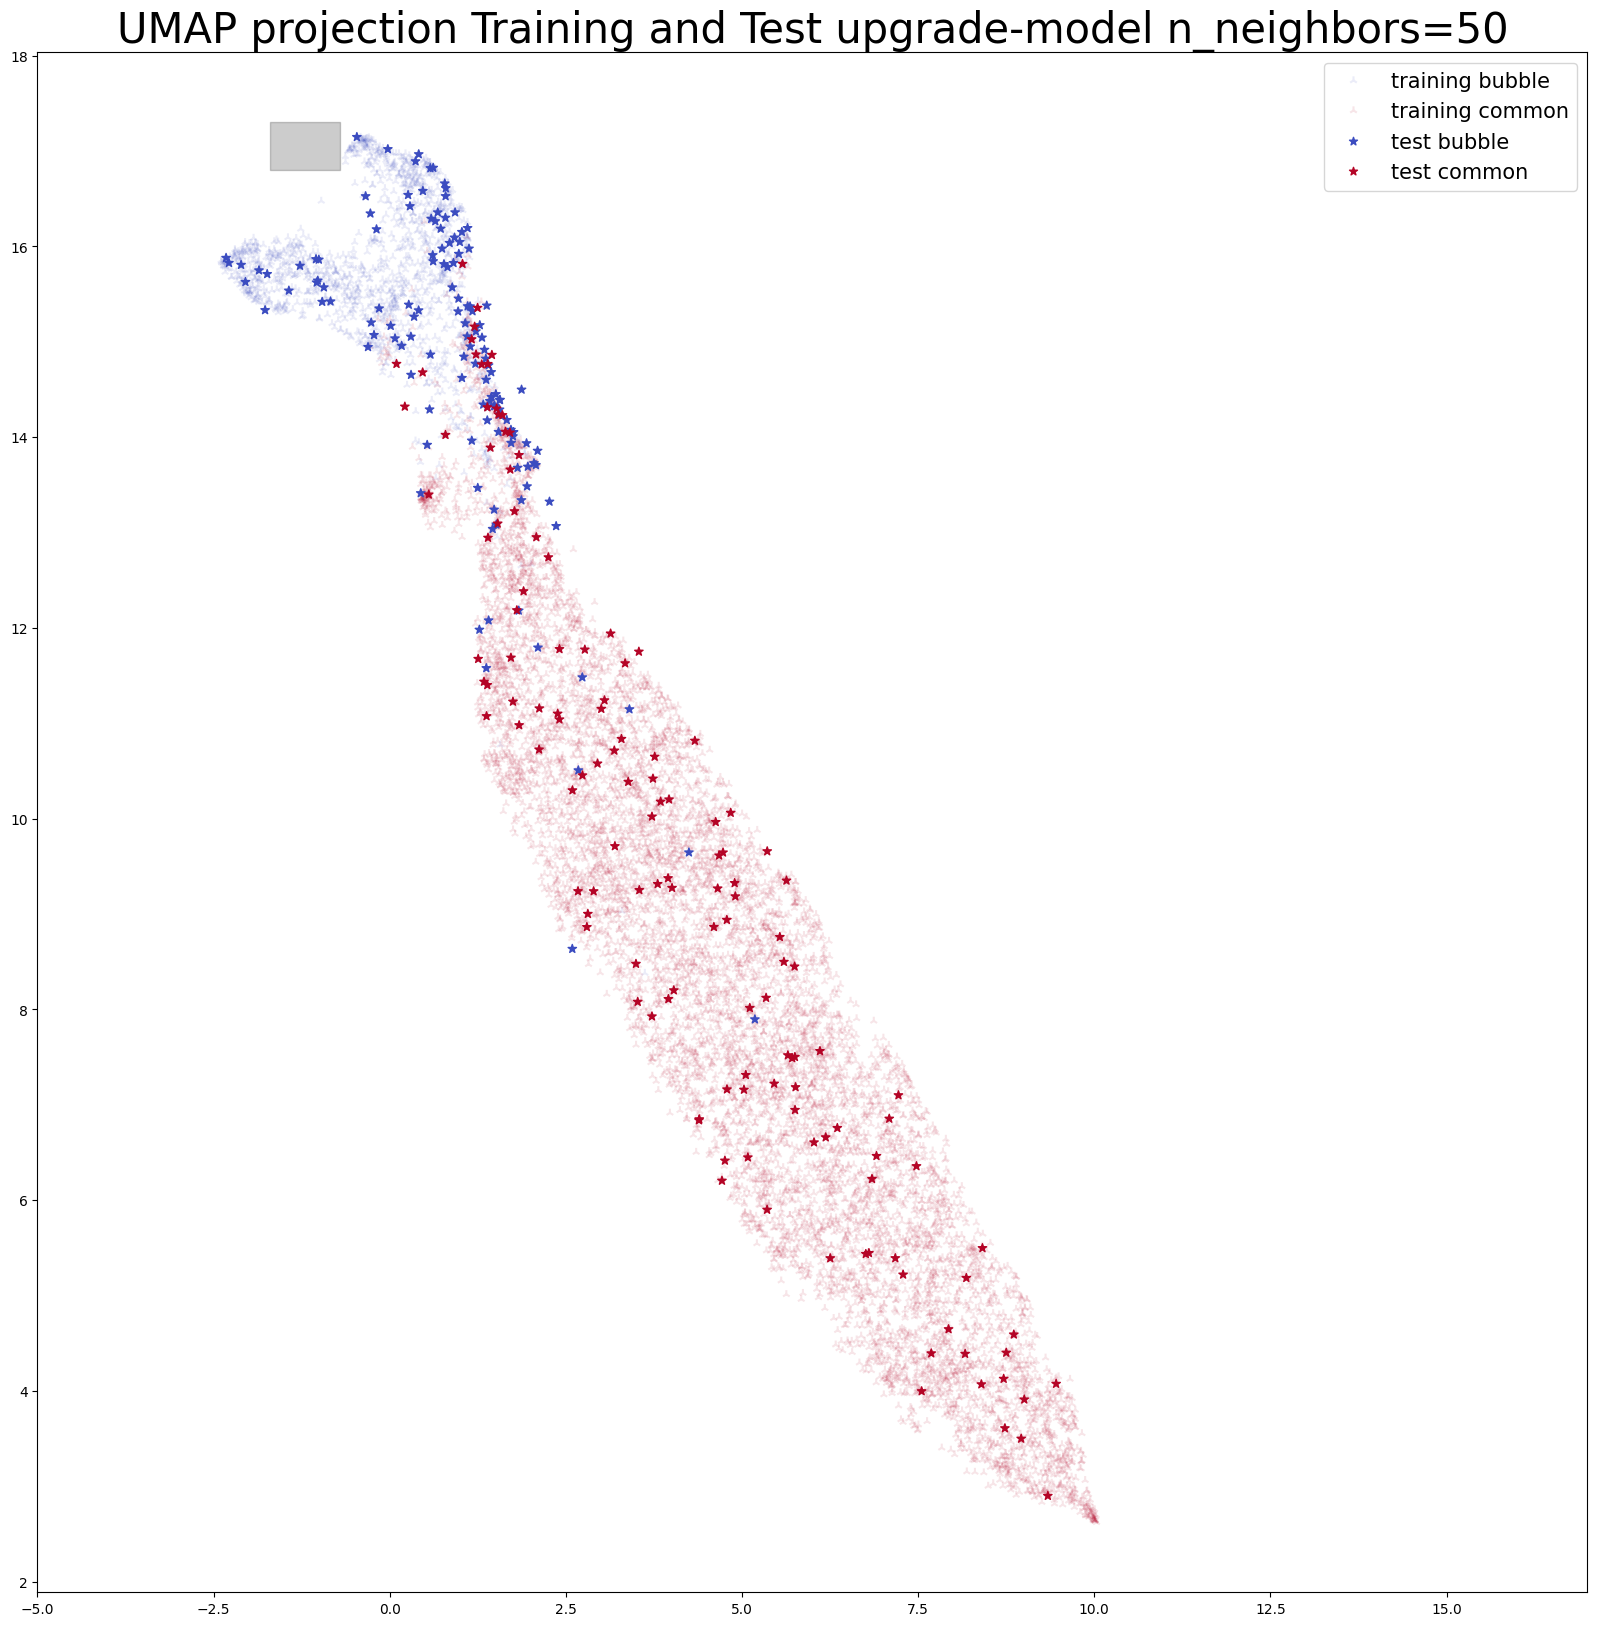

In [51]:
plt.figure(figsize=(20, 20))

# 1. 元のデータ（no, bubble）をプロット
scatter_orig = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=training_labels_set,
    cmap="coolwarm",  # 0と1（noとbubble）用のカラーマップ
    marker="2",
    alpha=0.1,   # 元データを少し透過させるとダミーデータが見やすくなります
)

scatter_test = plt.scatter(
    embedding_test[:, 0],
    embedding_test[:, 1],
    c=test_labels_set, 
    cmap="coolwarm",
    s=40,
    marker="*",       
    # edgecolors="black",
    # linewidths=0.5,
)

# --- 凡例（Legend）の調整 ---
# 元データ（no, bubble）のハンドルを取得
handles_orig, _ = scatter_orig.legend_elements()
handles_test, _ = scatter_test.legend_elements()
# handles_03400, _ = scatter_03400.legend_elements()

all_handles = handles_orig + handles_test
all_labels = ["training bubble", "training common", "test bubble", "test common"]

# まとめて凡例を表示
plt.legend(all_handles, all_labels, loc="upper right", fontsize=15)
# ----------------------------

plt.xlim(-5, 17)
# plt.ylim(-2.5, 8.2)
# plt.gca().set_aspect("equal", "box")
plt.title(f"UMAP projection Training and Test upgrade-model n_neighbors={n_neighbors}", fontsize=30)

for r in regions:
    # 網掛けの描画
    select_x_min = r["x"][0]
    select_x_max = r["x"][1]
    select_y_min = r["y"][0]
    select_y_max = r["y"][1]
    
    plt.fill_between(r["x"], select_y_min, select_y_max, color="black", alpha=0.2, zorder=1)
    
    # テキストを表示する中心座標の計算
    x_center = sum(r["x"]) / 2
    y_center = sum(r["y"]) / 2

    # 平均値の計算
    condition = (embedding_all[:, 0] > select_x_min) & (embedding_all[:, 0] < select_x_max) & (embedding_all[:, 1] > select_y_min)  & (embedding_all[:, 1] < select_y_max)
    isolated_indices = np.where(condition)[0]
    isolated_data = training_data_to_check_isolate[isolated_indices]
    axes_num = isolated_data[0].shape[0]
    
    # テキストの配置
    plt.text(
        x_center, 
        y_center+0.15, 
        r["name"], 
        fontsize=12, 
        fontweight="bold",
        color="black",
        ha="center",       # 水平方向の中央揃え
        va="center",       # 垂直方向の中央揃え
        zorder=2,          # 網掛けより前面に表示
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none") # 文字の背景（不要なら削除してください）
    )

    plt.text(
        x_center, 
        y_center-0.05, 
        f"mean: ", 
        fontsize=10, 
        fontweight="bold",
        color="blue",
        ha="center",       # 水平方向の中央揃え
        va="center",       # 垂直方向の中央揃え
        zorder=2,          # 網掛けより前面に表示
        # bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none") # 文字の背景（不要なら削除してください）
    )
    
    plt.text(
        x_center, 
        y_center-0.15, 
        f"{np.mean(isolated_data):.4f}", 
        fontsize=12, 
        fontweight="bold",
        color="cyan",
        ha="center",       # 水平方向の中央揃え
        va="center",       # 垂直方向の中央揃え
        zorder=2,          # 網掛けより前面に表示
        # bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none") # 文字の背景（不要なら削除してください）
    )

plt.grid(ls="dashdot")
plt.tight_layout()
# plt.savefig(f"UMAP_projection_Training_and_Test_upgrade-model_n_neighbors_{n_neighbors}_edge.png")
plt.show()

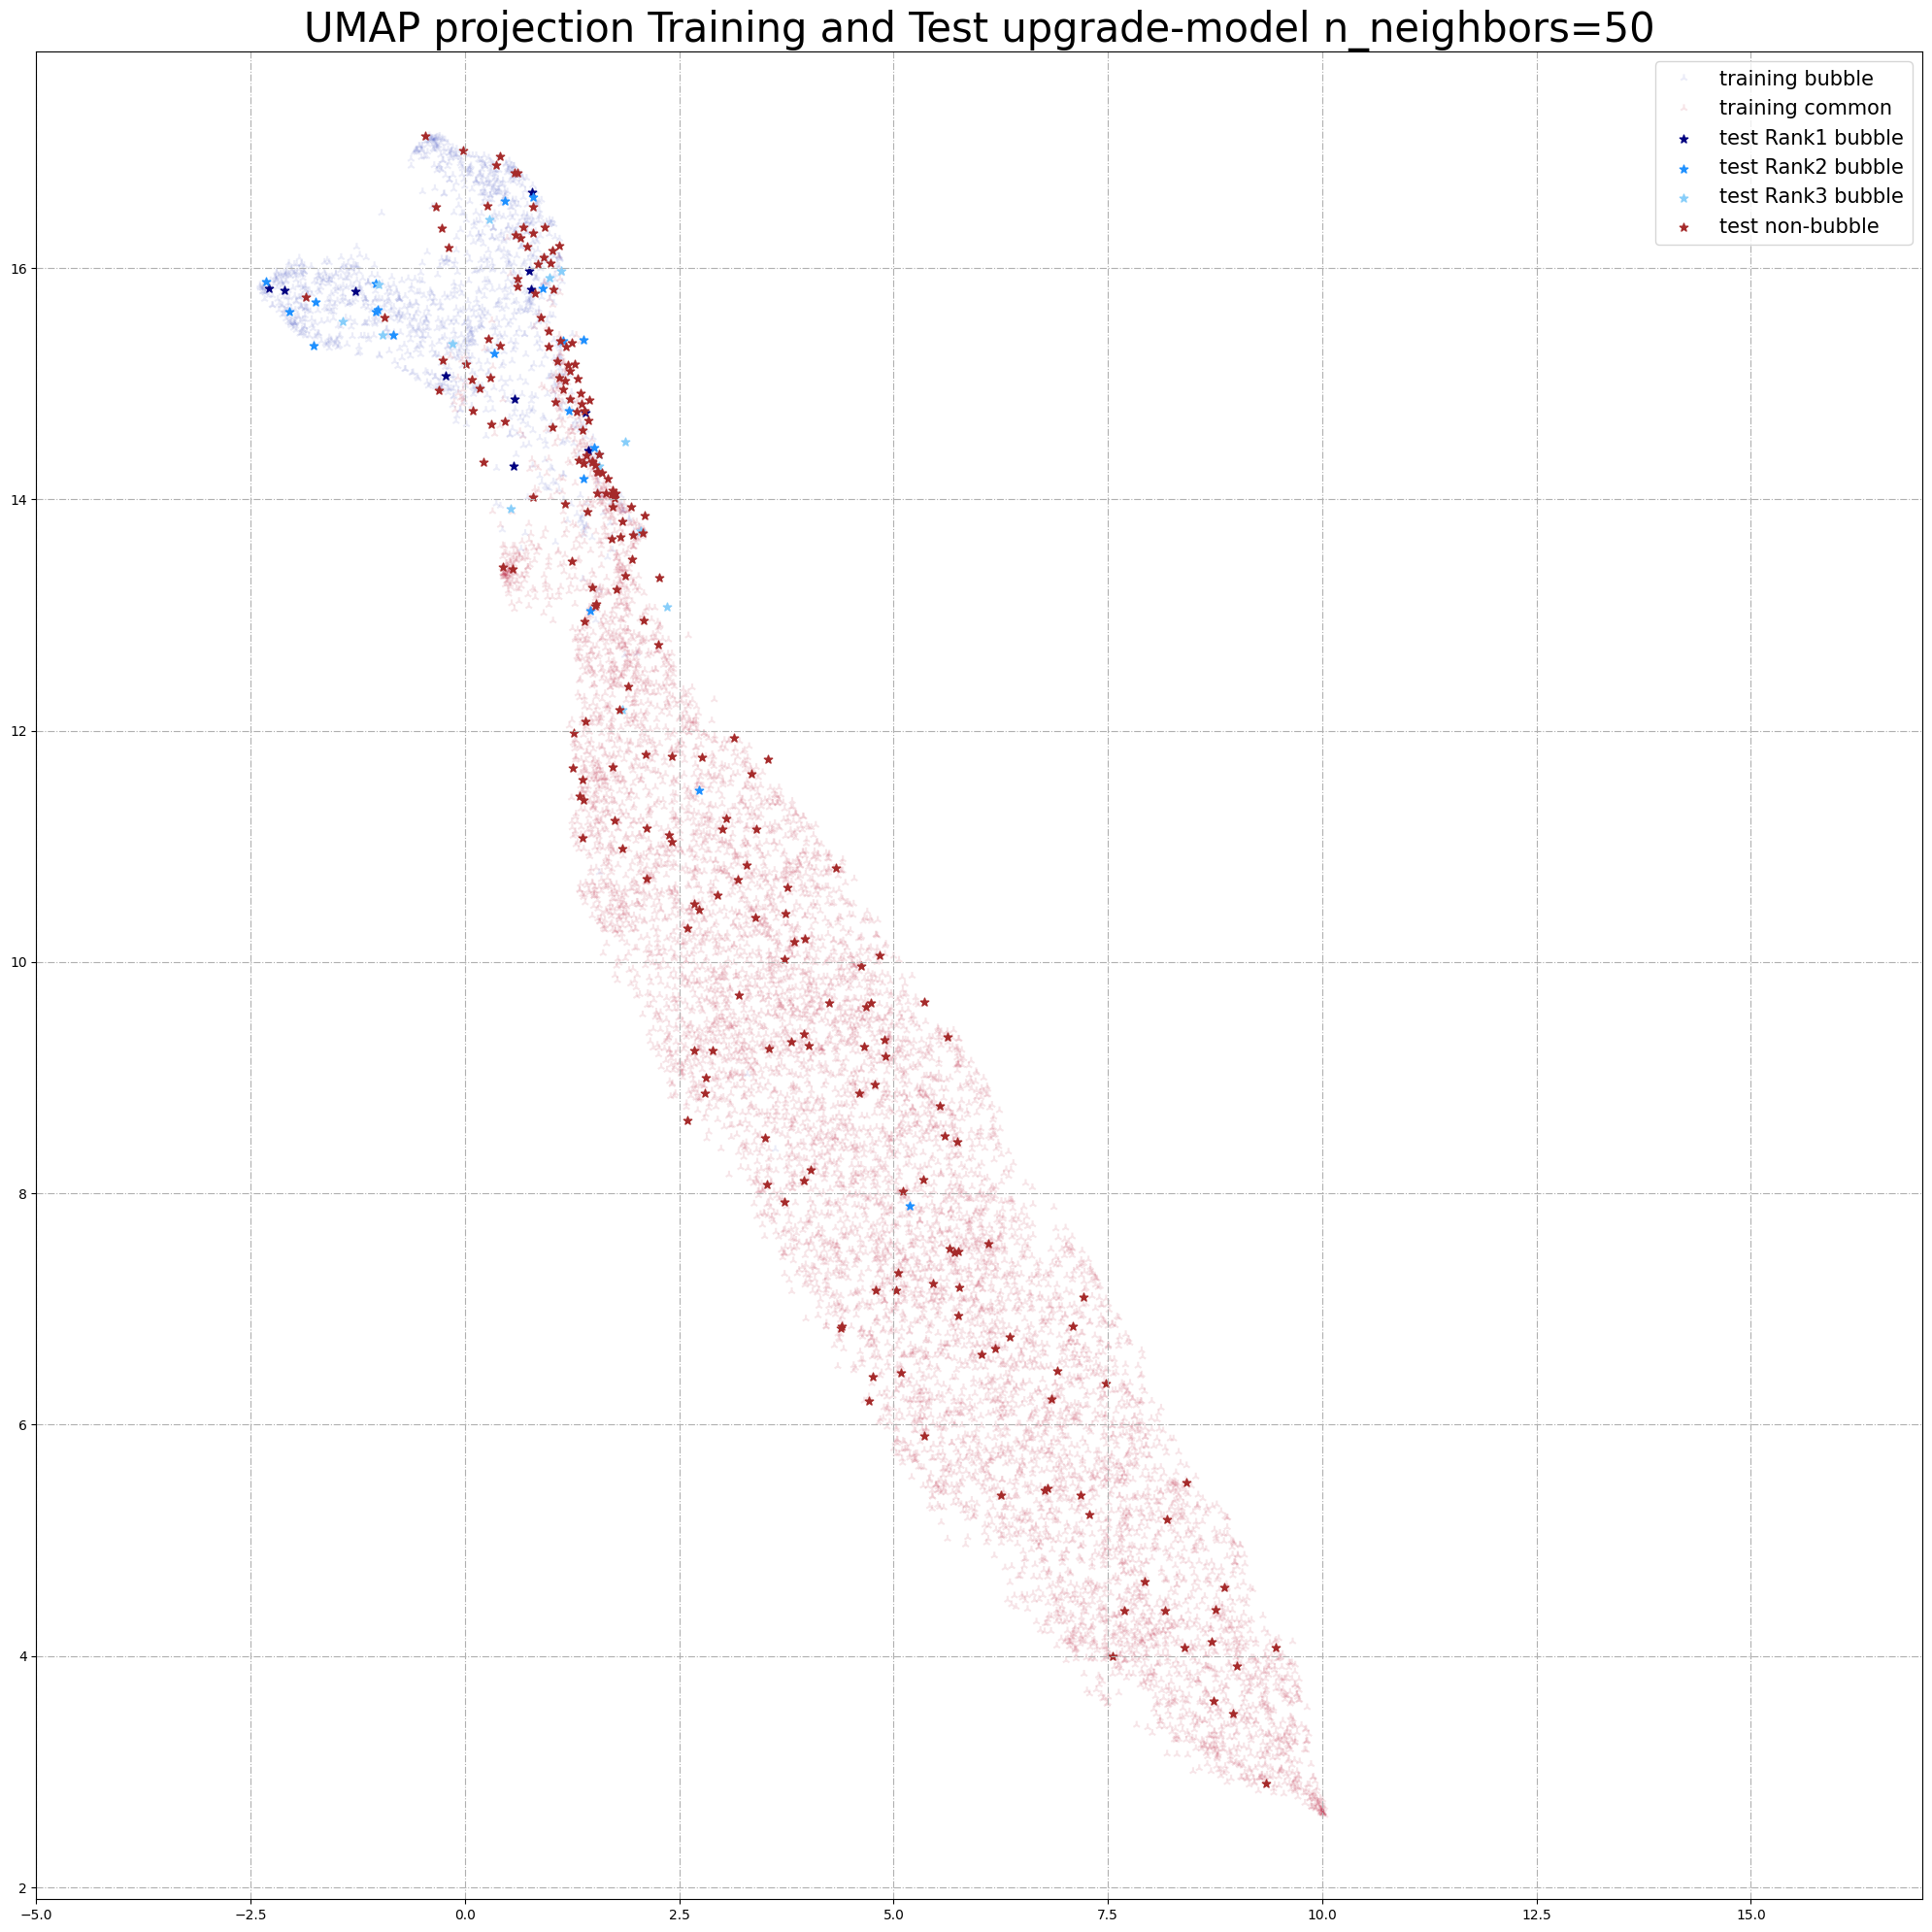

In [52]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))

# 1. 元のデータ（no, bubble）をプロット
scatter_orig = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=training_labels_set,
    cmap="coolwarm",  # 0と1（noとbubble）用のカラーマップ
    marker="2",
    alpha=0.1,   # 元データを少し透過させるとダミーデータが見やすくなります
)

# --- test データのランク別インデックスの抽出 ---
# 個数の構成: [7, 13, 8, 5, 7, 6]
# 順序の構成: [rank1, rank2, rank3, rank1, rank2, rank3]
# スライスに基づいて、各ランクのインデックスを結合します
idx_rank1 = list(range(0, 7)) + list(range(28, 33))
idx_rank2 = list(range(7, 20)) + list(range(33, 40))
idx_rank3 = list(range(20, 28)) + list(range(40, 46))

# 2. test データをランクごとにプロット（明るい青から濃い青へ）
scatter_rank1 = plt.scatter(
    embedding_test[idx_rank1, 0],
    embedding_test[idx_rank1, 1],
    c="navy",  # Rank1: 一番明るい青
    s=40,
    marker="*",
)

scatter_rank2 = plt.scatter(
    embedding_test[idx_rank2, 0],
    embedding_test[idx_rank2, 1],
    c="dodgerblue",    # Rank2: 中間の青
    s=40,
    marker="*",
)

scatter_rank3 = plt.scatter(
    embedding_test[idx_rank3, 0],
    embedding_test[idx_rank3, 1],
    c="lightskyblue",          # Rank3: 濃い青
    s=40,
    marker="*",
)

scatter_test_non_bubble = plt.scatter(
    embedding_test[46:, 0],
    embedding_test[46:, 1],
    c="brown",
    s=40,
    marker="*",
)

# --- 凡例（Legend）の調整 ---
# 元データ（no, bubble）のハンドルを取得
handles_orig, _ = scatter_orig.legend_elements()

# 元データのハンドルに、新しく作成したランクごとのプロットオブジェクトを追加
all_handles = handles_orig + [scatter_rank1, scatter_rank2, scatter_rank3, scatter_test_non_bubble]
all_labels = ["training bubble", "training common", "test Rank1 bubble", "test Rank2 bubble", "test Rank3 bubble", "test non-bubble"]

# まとめて凡例を表示
plt.legend(all_handles, all_labels, loc="upper right", fontsize=15)
# ----------------------------

plt.xlim(-5, 17)
# plt.ylim(-2.5, 8.2)
# plt.gca().set_aspect("equal", "box")
plt.title(f"UMAP projection Training and Test upgrade-model n_neighbors={n_neighbors}", fontsize=30)
plt.grid(ls="dashdot")
plt.tight_layout()
# plt.savefig(f"UMAP_projection_Training_and_Test_upgrade-model_n_neighbors_{n_neighbors}_edge.png")
plt.show()

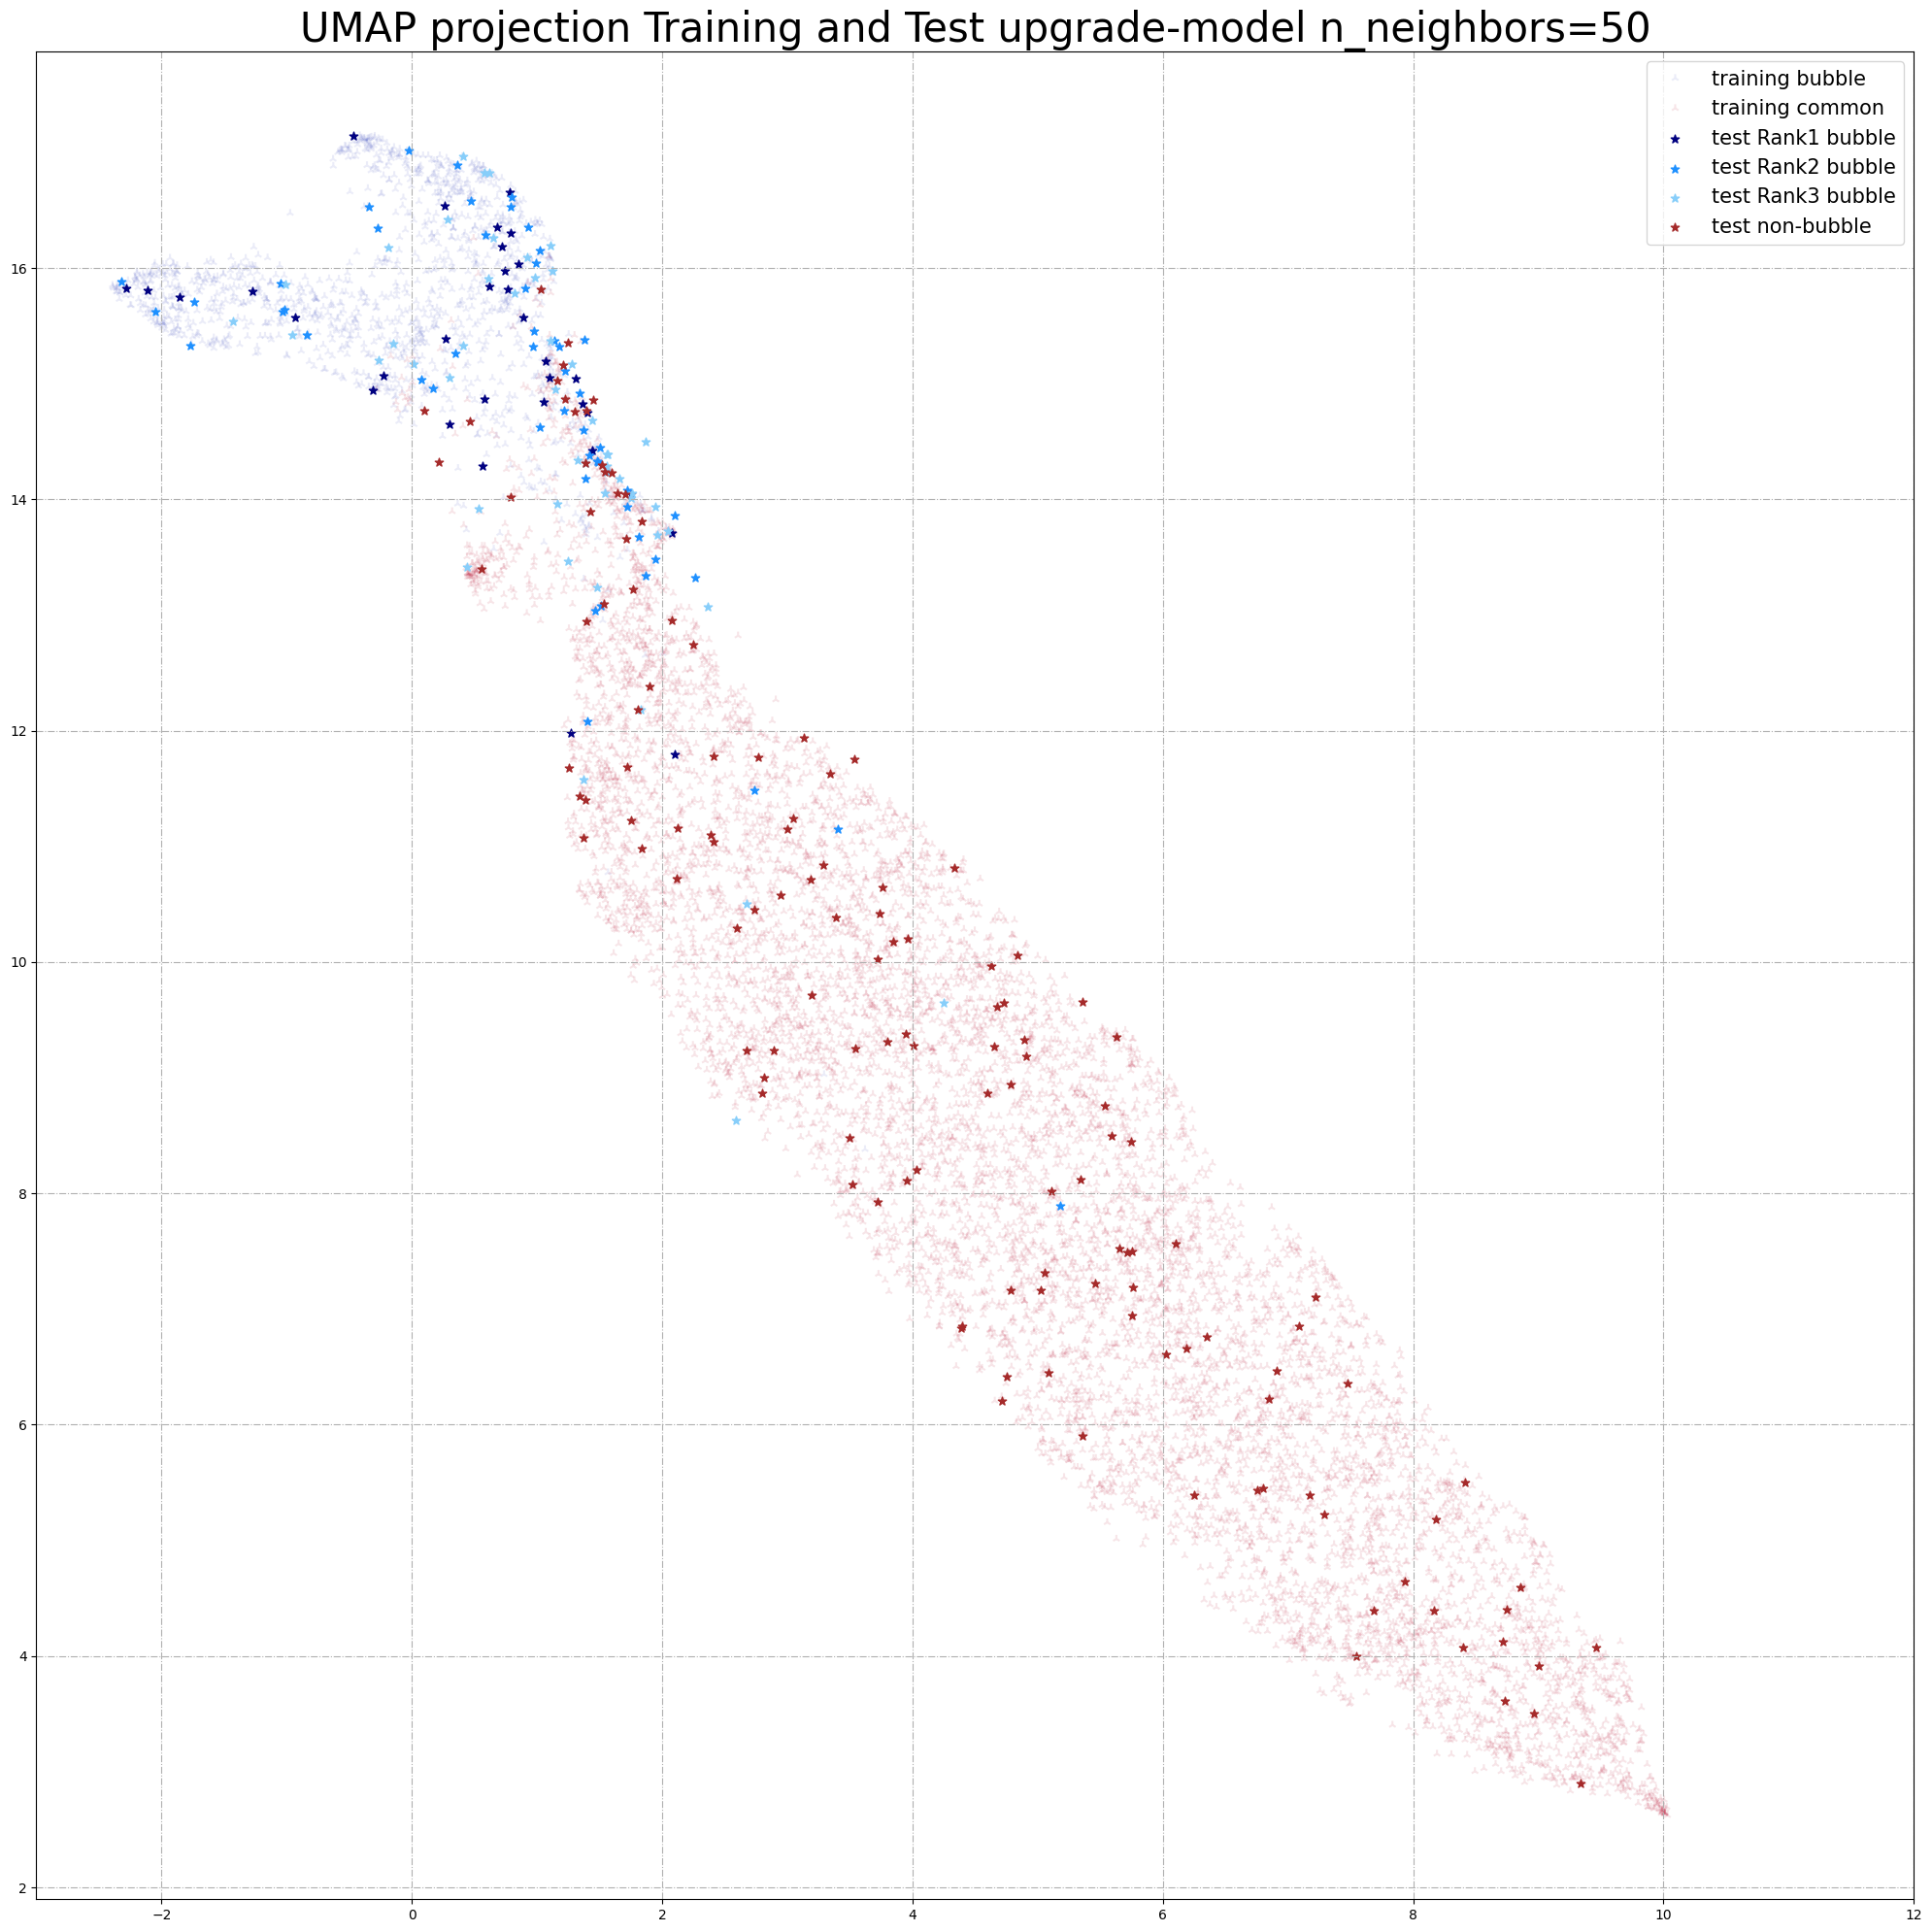

In [56]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))

# 1. 元のデータ（no, bubble）をプロット
scatter_orig = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=training_labels_set,
    cmap="coolwarm",  # 0と1（noとbubble）用のカラーマップ
    marker="2",
    alpha=0.1,   # 元データを少し透過させるとダミーデータが見やすくなります
)

# --- test データのランク別インデックスの自動抽出 ---
test_bubble_num_per_rank = [7, 13, 8, 5, 7, 6, 3, 4, 9, 6, 4, 5, 3, 8, 9, 5, 8, 9, 4, 7, 3]

idx_rank1 = []
idx_rank2 = []
idx_rank3 = []

current_idx = 0
for i, num in enumerate(test_bubble_num_per_rank):
    rank = (i % 3) + 1  # 1, 2, 3 の繰り返し
    indices = list(range(current_idx, current_idx + num))
    
    if rank == 1:
        idx_rank1.extend(indices)
    elif rank == 2:
        idx_rank2.extend(indices)
    elif rank == 3:
        idx_rank3.extend(indices)
        
    current_idx += num

# 2. test データをランクごとにプロット（明るい青から濃い青へ）
scatter_rank1 = plt.scatter(
    embedding_test[idx_rank1, 0],
    embedding_test[idx_rank1, 1],
    c="navy",  # Rank1: 一番明るい青（修正済）
    s=40,
    marker="*",
)

scatter_rank2 = plt.scatter(
    embedding_test[idx_rank2, 0],
    embedding_test[idx_rank2, 1],
    c="dodgerblue",    # Rank2: 中間の青
    s=40,
    marker="*",
)

scatter_rank3 = plt.scatter(
    embedding_test[idx_rank3, 0],
    embedding_test[idx_rank3, 1],
    c="lightskyblue",          # Rank3: 濃い青（修正済）
    s=40,
    marker="*",
)

# test_bubble の合計個数（133個）以降のデータを non-bubble としてプロット
scatter_test_non_bubble = plt.scatter(
    embedding_test[current_idx:, 0],  # 133: と直接書く代わりに動的な変数を使用
    embedding_test[current_idx:, 1],
    c="brown",
    s=40,
    marker="*",
)

# --- 凡例（Legend）の調整 ---
# 元データ（no, bubble）のハンドルを取得
handles_orig, _ = scatter_orig.legend_elements()

# 元データのハンドルに、新しく作成したランクごとおよび non-bubble のプロットオブジェクトを追加
all_handles = handles_orig + [scatter_rank1, scatter_rank2, scatter_rank3, scatter_test_non_bubble]
all_labels = ["training bubble", "training common", "test Rank1 bubble", "test Rank2 bubble", "test Rank3 bubble", "test non-bubble"]

# まとめて凡例を表示
plt.legend(all_handles, all_labels, loc="upper right", fontsize=15)
# ----------------------------

plt.xlim(-3, 12)
# plt.ylim(-2.5, 8.2)
# plt.gca().set_aspect("equal", "box")
plt.title(f"UMAP projection Training and Test upgrade-model n_neighbors={n_neighbors}", fontsize=30)
plt.grid(ls="dashdot")
plt.tight_layout()
# 仮想環境の仕様上、直接表示する代わりにファイル保存を推奨します
plt.savefig(f"UMAP_projection_Training_and_Test_upgrade-model_n_neighbors_{n_neighbors}_edge.png")
plt.show()

In [ ]:
for r in regions:
    print(f"--------------- Start {r['name']} ---------------")
    select_x_min = r["x"][0]
    select_x_max = r["x"][1]
    select_y_min = r["y"][0]
    select_y_max = r["y"][1]
    
    condition = (embedding_all[:, 0] > select_x_min) & (embedding_all[:, 0] < select_x_max) & (embedding_all[:, 1] > select_y_min)  & (embedding_all[:, 1] < select_y_max)
    
    # 2. 条件を満たすデータのインデックス（何番目か）を取得
    isolated_indices = np.where(condition)[0]
    
    print("該当するデータのインデックス（何番目か）:", isolated_indices)
    print("数 :", len(isolated_indices))

    isolated_data = training_data_to_check_isolate[isolated_indices]
    axes_num = isolated_data[0].shape[0]
    
    for index in range(len(isolated_data)):
        data = isolated_data[index]
        
        fig, axes = plt.subplots(1, axes_num, figsize=(axes_num*3, 1*4))
        for j, data_segment in enumerate(data):
            axes[j].imshow(data_segment, vmin=0, vmax=1, cmap="jet")
            axes[j].axis("off")
            axes[j].set_title(f"{j+1}ch", fontsize=20, color='red')
            
        # fig.suptitle(f"Data No.{index}, judge: {judgement_list[len(test_bubble):][index]}", fontsize=30, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f"{r['name']}_isolate_channel_map_middle_{index}.png")
        plt.show()

In [ ]:
for r in regions:
    select_x_min = r["x"][0]
    select_x_max = r["x"][1]
    select_y_min = r["y"][0]
    select_y_max = r["y"][1]

    condition = (embedding_all[:, 0] > select_x_min) & (embedding_all[:, 0] < select_x_max) & (embedding_all[:, 1] > select_y_min)  & (embedding_all[:, 1] < select_y_max)
    
    # 2. 条件を満たすデータのインデックス（何番目か）を取得
    isolated_indices = np.where(condition)[0]
    
    print("該当するデータのインデックス（何番目か）:", isolated_indices)
    print("数 :", len(isolated_indices))

    isolated_data = training_data_to_check_isolate[isolated_indices]
    axes_num = isolated_data[0].shape[0]
    print(np.mean(isolated_data))

In [ ]:
isolated_data = training_data_to_check_isolate[isolated_indices]

fig, axes = plt.subplots(1, len(isolated_data), figsize=(2*len(isolated_data), 2))
axes_flat = axes.flatten()
for i in range(len(isolated_data)):
    ax = axes_flat[i]
    data = isolated_data[i]
    ax.imshow(np.sum(data, axis=0), cmap="jet", vmin=0, vmax=12)
    ax.axis("off")
# plt.savefig("isolate_data.png")
plt.show()

In [ ]:
ex_num1 = 4000
ex_num2 = 5000

common_ex = training_data_to_check_isolate[[ex_num1, ex_num2]]

fig, axes = plt.subplots(1, len(common_ex), figsize=(2*len(common_ex), 2))
axes_flat = axes.flatten()
for i in range(len(common_ex)):
    ax = axes_flat[i]
    data = common_ex[i]
    ax.imshow(np.sum(data, axis=0), cmap="jet", vmin=0, vmax=10)
    ax.axis("off")
plt.tight_layout()
# plt.savefig("common_ex_data.png")
plt.show()

In [ ]:
axes_num = isolated_data[0].shape[0]
print(axes_num)

for index in range(len(isolated_data)):
    data = isolated_data[index]
    
    fig, axes = plt.subplots(1, axes_num, figsize=(axes_num*3, 1*4))
    for j, data_segment in enumerate(data):
        axes[j].imshow(data_segment, vmin=0, vmax=1, cmap="jet")
        axes[j].axis("off")
        axes[j].set_title(f"{j+1}ch", fontsize=20, color='red')
        
    # fig.suptitle(f"Data No.{index}, judge: {judgement_list[len(test_bubble):][index]}", fontsize=30, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"isolate_channel_map_middle_{index}.png")
    plt.show()

In [ ]:
axes_num = common_ex[0].shape[0]
print(axes_num)

for index in range(len(common_ex)):
    data = common_ex[index]
    
    fig, axes = plt.subplots(1, axes_num, figsize=(axes_num*3, 1*4))
    for j, data_segment in enumerate(data):
        axes[j].imshow(data_segment, vmin=0, vmax=1, cmap="jet")
        axes[j].axis("off")
        axes[j].set_title(f"{j+1}ch", fontsize=20, color='red')
        
    # fig.suptitle(f"Data No.{index}, judge: {judgement_list[len(test_bubble):][index]}", fontsize=30, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"common_ex_channel_map_{index}.png")
    plt.show()

In [ ]:
# 3つの配列を定義
data1 = isolate_latent[0]
data2 = isolate_latent[1]
data3 = isolate_latent[2]
data4 = all_data_set[ex_num1]
data5 = all_data_set[ex_num2]


# グラフのプロット（markerを設定すると、各データ点の位置が分かりやすくなります）
plt.figure(figsize=(18, 6))
plt.plot(data1, label='isolate1', marker='o', color="r")
plt.plot(data2, label='isolate2', marker='s', color="r")
plt.plot(data3, label='isolate3', marker='^', color="r")
plt.plot(data4, label='common ex1', marker='.', color="b")
plt.plot(data5, label='common ex2', marker=',', color="b")


# グラフの装飾
plt.title('Line Plot of Isolate Latent Variable ')  # グラフのタイトル
plt.xlabel('Index')                     # X軸のラベル
plt.ylabel('Value')                     # Y軸のラベル
plt.grid(True)                          # 補助線の表示
plt.legend()                            # 凡例（データラベル）の表示


# グラフを表示
# plt.savefig("isolate_and_common_latet_plot.png")
plt.show()